# Set-up

In [ ]:
import os
from google.colab import userdata

# Get the token from the Secrets pane
github_token = userdata.get('Crecerelle-GitHub-Access')

# Set it as an environment variable for pip
os.environ['Crecerelle-GitHub-Access'] = github_token

# @markdown **Crecerelle:** Install the library from GitHub
!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/Hollfelder-Lab/crecerelle.git "pandas==2.2.2"

In [ ]:
# @markdown **Directory structure:** Set-up the directory structure to store the results of Crecerelle. We recommend connecting to your Google Drive. Otherwise, the directories will be created only temporarily in Colab. If you have already set-up the directory structure from a previous analysis, the existing directories will not be overwritten but only the new ones added.

connect_google_drive = True # @param {type:"boolean"}

if connect_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')

    root_directory = "/content/drive/My Drive"
else:
    root_directory = "/content"





Mounted at /content/drive


The following directory structure is then created:
```text
root_directory/
└── crecerelle_results/
    ├── data/
    │   └── <dataset_name>/  *(optional)*
    ├── figures/
    │   └── <dataset_name>/  *(optional)*
    └── models/
        ├── scGETUVI/
        ├── scTUVI/
        └── scVI/

In [ ]:
from crecerelle.utils import setup_crecerelle

# @markdown **Dataset name:** Define the dataset name
dataset_name = "tabulaMuris" # @param

# Set-up the directory structure
setup_crecerelle(root_directory, dataset_name=dataset_name)

# @markdown The working directory is then set to "./crecerelle_results"
if os.path.basename(os.path.normpath(os.getcwd())) != "crecerelle_results":
    os.chdir("drive/My Drive/crecerelle_results")

# Print the working directory
print(f"The working directory is set to: {os.getcwd()}")

Skipped (already exists): /content/drive/My Drive/crecerelle_results
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scTUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scGETUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data/tabulaMuris
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures/tabulaMuris
The working directory is set to: /content/drive/My Drive/crecerelle_results


In [ ]:
# @markdown **Imports:** modules from PyTorch, Numpy, Scanpy amongst others are imported together with the crecerelle modules necessary for training of scGETUVI
# General import
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from umap import UMAP
import scib

# Imports from crecerelle
from crecerelle.models import SCGETUVI
from crecerelle.training_utils import train_MMVAEplus, save_model_checkpoint
from crecerelle.cell import TABULA_MURIS_CELL_TYPES, MOUSE_CORTEX_BICCN_CELL_TYPES, TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT, TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT
from crecerelle.utils import GeneExpressionTranscriptUsageDataset, intron_names_2_integers

# Settings for plotting
plt.rcParams.update({
    'font.size': 16,              # General font size
    'axes.labelsize': 16,         # Font size for x and y labels
    'axes.titlesize': 16,         # Font size for subplot titles
    'xtick.labelsize': 16,        # Font size for x-axis tick labels
    'ytick.labelsize': 16,        # Font size for y-axis tick labels
    'legend.fontsize': 16,        # Font size for legend labels
    #'font.family': 'sans-serif',
    #'font.sans-serif': 'Roboto',
    # 'figure.titlesize': 10,    # Font size for the overall figure title (if you use it)
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# @markdown **Specify settings:** These are the general settings for keys to be defined. They are stored in a dictionary called settings. The dataset_name key is already saved in it. The current settings contain the default version for the Tabula Muris dataset.

# @markdown Key of Anndata object specifiying the cell type
settings_cell_type_key = "cell_ontology_class" # @param

# @markdown  Cell types of dataset given
settings_cell_types = TABULA_MURIS_CELL_TYPES # @param

# @markdown Abbreviations of cell types
settings_cell_type_abbreviations = TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT # @param

# @markdown Organisational entity of cell groups (e.g. tissue)
settings_cell_type_groups_key = "tissue" # @param

# @markdown Name of gene annotation file
settings_gene_annotation = "Mus_musculus.GRCm38.102.chr.gtf.gz" # @param

# @markdown Number of highly variable genes selected (HVGs)
settings_num_hvg = 3000 # @param

# @markdown Data partition used (recommended: "full") for tasks
settings_data_type = "full" # @param

# @markdown Key of Anndata object specifying the data partition (e.g. "train", "val", "test)
settings_data_partition_key = "data_partition" # @param

# @markdown Filter data to cell types with a minimum count
settings_filter_cell_types = True # @param {type:"boolean"}

# @markdown Minimum count threshold for filtering if filter_cell_types is True
settings_min_count_threshold = 100 # @param {type:"integer"}

settings = {
    "dataset_name": dataset_name, # Name of dataset
    "cell_type_key": settings_cell_type_key, # Key of Anndata object specifiying the cell type
    "cell_types": settings_cell_types, # Cell types of dataset given
    "cell_type_abbreviations": settings_cell_type_abbreviations, # Abbreviations of cell types
    "cell_type_groups_key": settings_cell_type_groups_key, # Organisational entity of cell groups (e.g. tissue)
    "gene_annotation": settings_gene_annotation,
    "num_hvg": settings_num_hvg, # Number of highly variable genes selected (HVGs)
    "data_type": settings_data_type, # Data partition used (recommended: "full") for tasks
    "data_partition_key": settings_data_partition_key,
    "filter_cell_types": settings_filter_cell_types, # Filter data to cell types with a minimum count
    "min_count_threshold": settings_min_count_threshold, # Minimum count threshold for filtering if filter_cell_types is True
}

In [ ]:
# @markdown All data files must be stored here and the resulting new data will also be stored here.
path2data = "./data/" + settings["dataset_name"] + "/"

print(f"The data files will be stored in: {path2data}")

The data files will be stored in: ./data/tabulaMuris/


In [ ]:
# Run for work
#import os
#os.chdir("../scASpred")

#!pwd

# Loading of data

Ensure the Anndata objects of the gene expression and transcript usage data are uploaded in "./crecerelle_results/data/dataset_name" *(optional)*. The object containing the gene expression matrix should have the prefix "adata_GE" whereas the one containing the transcript usage matrix should start with "adata_TU". Examples are:




*   adata_GE_{data_type}_preprocessed.h5ad
    *   e.g. adata_GE_full_preprocessed.h5ad
*   adata_TU_{data_type}_preprocessed.h5ad
    *   e.g. adata_TU_full_preprocessed.h5ad
*   adata_GE_{num_hvg}_{data_partition}.h5ad
    *   adata_GE_3000_train.h5ad
    *   adata_GE_3000_val.h5ad
    *   adata_GE_3000_test.h5ad

In [ ]:
# @markdown **Dataset:** Choose the dataset for training with scGETUVI

hvg_annotation = np.load(path2data + "full_" + str(settings["num_hvg"]) + "_hvg_annotation.npy")

if settings["data_type"]  != "full":
    # Load gene expression data of specified data partition
    adata_GE = ad.read_h5ad(path2data + "adata_GE_" + settings["data_type"]  + "_preprocessed.h5ad")
    adata_GE = adata_GE[:, hvg_annotation].copy()
    adata_GE.obs[settings["data_partition_key"]] = settings["data_type"]

    print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE}")

    # Load transcript usage data of specified data partition
    adata_TU = ad.read_h5ad(path2data + "adata_TU_" + settings["data_type"]  + "_preprocessed.h5ad")
    intron_groups_by_name = adata_TU.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU.obs[settings["data_partition_key"]] = settings["data_type"]

    print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU}")
else:
    # Load gene expression training data
    adata_GE_train = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_train.h5ad")
    adata_GE_train = adata_GE_train[:, hvg_annotation].copy()
    adata_GE_train.obs[settings["data_partition_key"]] = "train"

    # Load transcript usage training data
    adata_TU_train = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_train.h5ad")
    intron_groups_by_name = adata_TU_train.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU_train.obs[settings["data_partition_key"]] = "train"

    # Load gene expression validation data
    adata_GE_val = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_GE_val = adata_GE_val[:, hvg_annotation].copy()
    adata_GE_val.obs[settings["data_partition_key"]] = "val"

    # Load transcript usage validation data
    adata_TU_val = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_TU_val.obs[settings["data_partition_key"]] = "val"

    # Load gene expression test data
    adata_GE_test = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_GE_test = adata_GE_test[:, hvg_annotation].copy()
    adata_GE_test.obs[settings["data_partition_key"]] = "test"

    # Load transcript usage test data
    adata_TU_test = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_TU_test.obs[settings["data_partition_key"]] = "test"

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_GE_train.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train, adata_GE_val, adata_GE_test to filtered_cell_types
        adata_GE_train_filtered = adata_GE_train[adata_GE_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_val_filtered = adata_GE_val[adata_GE_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_test_filtered = adata_GE_test[adata_GE_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_GE_train = adata_GE_train_filtered
        adata_GE_val = adata_GE_val_filtered
        adata_GE_test = adata_GE_test_filtered

        # Filter adata_TU_train, adata_TU_val, adata_TU_test accordingly
        adata_TU_train_filtered = adata_TU_train[adata_TU_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_val_filtered = adata_TU_val[adata_TU_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_test_filtered = adata_TU_test[adata_TU_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU_train = adata_TU_train_filtered
        adata_TU_val = adata_TU_val_filtered
        adata_TU_test = adata_TU_test_filtered

        print(f"Cell types with less than {settings["min_count_threshold"]} have been filtered out. \n")

    adata_GE = ad.concat([adata_GE_train, adata_GE_val, adata_GE_test], axis=0, join="outer", merge="same")
    adata_TU = ad.concat([adata_TU_train, adata_TU_val, adata_TU_test], axis=0, join="outer", merge="same")

# @markdown **Optional: Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells (if not set to 0)
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_TU_filtered = adata_TU[keep_mask, :].copy()
    adata_GE_filtered = adata_GE[keep_mask, :].copy()

    adata_TU_filtered.obs[settings["cell_type_key"]] = adata_TU_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()
    adata_GE_filtered.obs[settings["cell_type_key"]] = adata_GE_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_TU = adata_TU_filtered.copy()
    adata_TU_train = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_TU_val = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_TU_test = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "test", :].copy()

    adata_GE = adata_GE_filtered.copy()
    adata_GE_train = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_GE_val = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_GE_test = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "test", :].copy()

    print(f"Cell types with less than {min_cells_per_tax_level} cells per taxonomy level have been filtered out. \n")

print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE} \n")
print(f"Following Anndata object contains the gene expression training data: \n {adata_GE_train} \n")
print(f"Following Anndata object contains the gene expression validation data: \n {adata_GE_val} \n")
print(f"Following Anndata object contains the gene expression test data: \n {adata_GE_test} \n")

print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU} \n")
print(f"Following Anndata object contains the transcript usage training data: \n {adata_TU_train} \n")
print(f"Following Anndata object contains the transcript usage validation data: \n {adata_TU_val} \n")
print(f"Following Anndata object contains the transcript usage test data: \n {adata_TU_test} \n")


Cell types with less than 100 have been filtered out. 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_3300/654808872.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetim

Cell types with less than 50 cells per taxonomy level have been filtered out. 

Following Anndata object contains the gene expression data of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'lo

In [ ]:
# @markdown **Dataset and dataloader:** Create the training and validation dataset of transcript usage and corresponding dataloader for scTUVI

# @markdown **Batch size:** Choose the batch size for training. It is recommended to use batch sizes that are powers of 2 and greater than 100
batch_size = 256 # @param {type:"number"}

# Extract gene expression training data from AnnData object
cell_gene_counts_train = torch.from_numpy(adata_GE_train.layers["counts"].toarray())
cell_gene_levels_train = torch.from_numpy(adata_GE_train.X.toarray())

# Extract transript usage training data from AnnData object
cell_intron_counts_train = torch.from_numpy(adata_TU_train.layers["counts"].toarray())
cell_intron_levels_train = torch.from_numpy(adata_TU_train.X.toarray())

transform_gene_counts_train = None
transform_ontology_train = "one-hot"
transform_intron_counts_train = None # Previously "log" but incorrect
transform_intron_levels_train = None

train_dataset = GeneExpressionTranscriptUsageDataset(
    cell_gene_counts=cell_gene_counts_train,
    cell_gene_levels=cell_gene_levels_train,
    cell_intron_counts=cell_intron_counts_train,
    cell_intron_levels=cell_intron_levels_train,
    ontology=adata_GE.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_GE.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types=cell_types,
    transform_gene_counts=transform_gene_counts_train,
    transform_intron_counts=transform_intron_counts_train,
    transform_intron_levels=transform_intron_levels_train,
    transform_ontology=transform_ontology_train
)

# Dataloader
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

print(f"The dataloader for the training dataset is set up.\n")

# Extract gene expression validation data from AnnData object
cell_gene_counts_val = torch.from_numpy(adata_GE_val.layers["counts"].toarray())
cell_gene_levels_val = torch.from_numpy(adata_GE_val.X.toarray())

# Extract transript usage validation data from AnnData object
cell_intron_counts_val = torch.from_numpy(adata_TU_val.layers["counts"].toarray())
cell_intron_levels_val = torch.from_numpy(adata_TU_val.X.toarray())

transform_gene_counts_val = None
transform_ontology_val = "one-hot"
transform_intron_counts_val = None # Previously "log" but incorrect
transform_intron_levels_val = None

val_dataset = GeneExpressionTranscriptUsageDataset(
    cell_gene_counts=cell_gene_counts_val,
    cell_gene_levels=cell_gene_levels_val,
    cell_intron_counts=cell_intron_counts_val,
    cell_intron_levels=cell_intron_levels_val,
    ontology=adata_GE.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_GE.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types=cell_types,
    transform_gene_counts=transform_gene_counts_val,
    transform_intron_counts=transform_intron_counts_val,
    transform_intron_levels=transform_intron_levels_val,
    transform_ontology=transform_ontology_val
)

# Dataloader
val_loader = DataLoader(val_dataset, batch_size, shuffle=True)

print(f"The dataloader for the validation dataset is set up.")

The dataloader for the training dataset is set up.

The dataloader for the validation dataset is set up.


# Single-cell Gene Expression and Transcript Usage Variational Inference (scGETUVI)

In [ ]:
# @markdown **Dimension of latent spaces:** Define the dimensionality of the private gene expression embeddings (latent_dim_1), of the private transcript usage embeddings (latent_dim_2), and the shared embeddings (latent_dim_shared)

# input_dim[0] for gene expression, input_dim[1] for transcript usage
input_dim = [train_dataset.num_genes, train_dataset.num_introns]

# number of intron groups for transcript usage # TO DO ELIMINATE THIS PARAMETER LATER
num_intron_groups = num_intron_groups

# intron groups for transcript usage # TO DO ELIMINATE THIS PARAMETER LATER
intron_groups = intron_groups

# latent_dim[0] for gene expression, latent_dim[1] for transcript usage, latent_dim[2] for shared latent
latent_dim_1 = 10 # @param {type:"integer"}
latent_dim_2 = 10 # @param {type:"integer"}
latent_dim_shared = 10 # @param {type:"integer"}
latent_dim = [latent_dim_1, latent_dim_2, latent_dim_shared]

# @markdown **Beta parameter:** Choose the value for the beta parameter for gene expression and transcript usage
# beta[0] for gene expression, beta[1] for transcript usage
beta_1 = 1.0 # @param {type:"number"}
beta_2 = 1.0 # @param {type:"number"}
beta = [beta_1, beta_2]

# @markdown **Architecture of neural networks:** choose the number of hidden layers as well as the number of hidden units per layer for the encoding and decoding neural networks of gene expression (num_hidden_layers_1, num_hidden_units_1) and transcript usage (num_hidden_layers_2, num_hidden_units_2)
# num_hidden_layers[0] for gene expression, num_hidden_layers[1] for transcript usage
num_hidden_layers_1 = 2 # @param {type:"integer"}
num_hidden_layers_2 = 2 # @param {type:"integer"}
num_hidden_layers = [num_hidden_layers_1, num_hidden_layers_2]

# num_hidden_units[0] for gene expression, num_hidden_units[1] for transcript usage
num_hidden_units_1 = 256 # @param {type:"integer"}
num_hidden_units_2 = 256 # @param {type:"integer"}
num_hidden_units = [num_hidden_units_1, num_hidden_units_2]

# @markdown **Observation model:** Choose the data likelihood of the gene expression data (likelihood_1) and of the transcript usage data (likelihood_2).
# likelihoods[0] for gene expression, likelihoods[1] for transcript usage
likelihood_1 = "ZINB" # @param ["ZINB", "NB","Gaussian"]
likelihood_2 = "ZIDM" # @param ["ZANIDM", "ZIDM", "DM"]
likelihoods = [likelihood_1, likelihood_2]

# @markdown **Data modality weighting:** Tick the box, if the importance of each modality for each data point shall be learnt
# Learn weighting of modalities
learn_modality_weighting = True # @param {type:"boolean"}

# @markdown **Dropout rate:** If dropout shall be applied, set the dropout rate to 0.0 > p > 1.0. Otherwise, choose 0.0.
dropout_rate = 0.1 # @param {type:"number"}
device = "cuda" # @param ["cuda", "cpu"]

scaling_factor_1 = False # @param {type:"boolean"}
scaling_factor_2 = False # @param {type:"boolean"}
scaling_factor = [scaling_factor_1, scaling_factor_2]

# Convert beta to string
for beta_i in beta:
    beta_str = f"{beta_i:.1f}"
    beta_str = beta_str.replace(".", "")
    while len(beta_str) < 3:
        beta_str = "0" + beta_str
    beta_str = beta_str

from crecerelle.models import SCGETUVI

# @markdown **Random seed:** select the random seed
seed = 9 # @param {type:"integer"} 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
torch.manual_seed(seed)
np.random.seed(seed)

model_name = "scGETUVI_" + str(seed) + "_" + likelihoods[0] + "_" + likelihoods[1] + "_" + beta_str
loss_type = "VariationalELBO"

model = SCGETUVI(
    input_dim=input_dim,
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    likelihoods=likelihoods,
    scaling_factor=scaling_factor,
    temp=500, # Parameter is now used as final value for modality regularisation
    learn_modality_weighting=learn_modality_weighting,
    dropout_rate=dropout_rate,
    device=device,
)

print(f"The given model specification for scGETUVI yields: \n {model}")



The given model specification for scGETUVI yields: 
 SCGETUVI(
  (vae_1): ZINBGeneExpressionVAE(
    (encoder): Encoder(
      (encoder): FCLayers(
        (fc_layers): ModuleList(
          (0): Sequential(
            (linear): Linear(in_features=3000, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): Sequential(
            (linear): Linear(in_features=256, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (mean_encoder): Linear(in_features=256, out_features=20, bias=True)
      (var_encoder): Linear(in_features=256, out_features=20, bias=True)
    )
    (decoder): ZINBGeneExpression

/usr/local/lib/python3.12/dist-packages/crecerelle/models.py:1560: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  torch.sparse_coo_tensor(


# Training

In [ ]:
# @markdown **Weight-Initialization:** The parameters of the constituent VAEs are initialised using Kaiminig-He


def init_weights_he(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

        print(f"{m} is initialised with Kaiming-He")

model.apply(init_weights_he)


Linear(in_features=3000, out_features=256, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=256, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=20, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=20, bias=True) is initialised with Kaiming-He
Linear(in_features=20, out_features=128, bias=True) is initialised with Kaiming-He
Linear(in_features=128, out_features=256, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=3000, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=3000, bias=True) is initialised with Kaiming-He
Linear(in_features=2319, out_features=256, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=256, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=20, bias=True) is initialised with Kaiming-He
Linear(in_features=256, out_features=20, bias=True) is initialised with Kaim

SCGETUVI(
  (vae_1): ZINBGeneExpressionVAE(
    (encoder): Encoder(
      (encoder): FCLayers(
        (fc_layers): ModuleList(
          (0): Sequential(
            (linear): Linear(in_features=3000, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): Sequential(
            (linear): Linear(in_features=256, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (mean_encoder): Linear(in_features=256, out_features=20, bias=True)
      (var_encoder): Linear(in_features=256, out_features=20, bias=True)
    )
    (decoder): ZINBGeneExpressionDecoder(
      (decoding_layers): FCLayers(
        (

In [ ]:
# @markdown **Importance weight encoder:** Intialise final weighting encoder layer such that equal weighting is ensured
torch.nn.init.constant_(model.weighting_encoder.scale_encoder.weight, 0.0)

torch.nn.init.constant_(model.weighting_encoder.scale_encoder.bias, 0.0)

Parameter containing:
tensor([0., 0.], requires_grad=True)

In [ ]:
# @markdown **GPU computation:** Push model to GPU if available
if torch.cuda.is_available():
    model.to(device)
else:
    model.to(device)

print(f"The given model specification for scGEVI yields: \n {model}")

The given model specification for scGEVI yields: 
 SCGETUVI(
  (vae_1): ZINBGeneExpressionVAE(
    (encoder): Encoder(
      (encoder): FCLayers(
        (fc_layers): ModuleList(
          (0): Sequential(
            (linear): Linear(in_features=3000, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): Sequential(
            (linear): Linear(in_features=256, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (mean_encoder): Linear(in_features=256, out_features=20, bias=True)
      (var_encoder): Linear(in_features=256, out_features=20, bias=True)
    )
    (decoder): ZINBGeneExpressionDe

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
   batch 10 loss: 2173.939501953125
        ELBO 1: 2028.61513671875, ELBO 2: 2086.61328125
        NLL 1: 2247.5351318359376, NLL 2: 575.5589599609375
        KLD 1: 13.777173042297363, KLD 2: 27.842409133911133
   batch 20 loss: 2171.9848876953124
        ELBO 1: 2046.1376831054688, ELBO 2: 2077.4629150390624
        NLL 1: 2227.298828125, NLL 2: 578.4069641113281
        KLD 1: 13.428655433654786, KLD 2: 27.75528907775879
   batch 30 loss: 2174.341455078125
        ELBO 1: 2056.242883300781, ELBO 2: 2081.329833984375
        NLL 1: 2232.2924560546876, NLL 2: 578.7585632324219
        KLD 1: 13.843212890625, KLD 2: 27.66362934112549
   batch 40 loss: 2183.0900634765626
        ELBO 1: 2066.7368041992186, ELBO 2: 2099.25537109375
        NLL 1: 2246.5658935546876, NLL 2: 584.9443115234375
        KLD 1: 13.800120162963868, KLD 2: 27.68267478942871
   batch 50 loss: 2202.509814453125
        ELBO 1: 2093.189489746094, E

SCGETUVI(
  (vae_1): ZINBGeneExpressionVAE(
    (encoder): Encoder(
      (encoder): FCLayers(
        (fc_layers): ModuleList(
          (0): Sequential(
            (linear): Linear(in_features=3000, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): Sequential(
            (linear): Linear(in_features=256, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (mean_encoder): Linear(in_features=256, out_features=20, bias=True)
      (var_encoder): Linear(in_features=256, out_features=20, bias=True)
    )
    (decoder): ZINBGeneExpressionDecoder(
      (decoding_layers): FCLayers(
        (

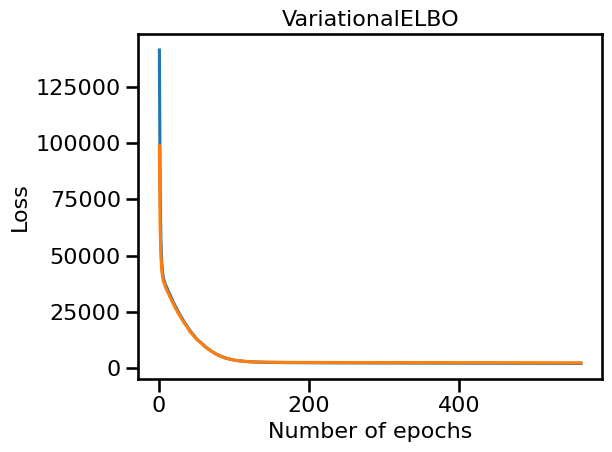

In [ ]:
# @markdown **Number of epochs:** Choose the number of epochs to train scGETUVI
num_epochs = 1000 # @param {type:"integer"} usually 200
# @markdown **Number of epochs for KL-warm up:** Choose the number of epochs, the KL divergence is linearly increased to the set values of beta
num_epochs_kl_warmup = 50 # @param {type:"integer"} usually 50
# @markdown **Temperature annealing:** Choose the number of epochs for temperature annealing of the modality weights
num_epochs_temp = 50 # @param {type:"integer"} NEW
# @markdown **Early stopping:** If early stopping shall be used, define the number of epochs without improvement after which the training is stopped
patience = 20 # @param {type:"integer"}
# @markdown **Initial learning rate:** Define the initial learning rate for the optimisation
init_lr = 0.0001 # @param {type:"number"}
# @markdown **Learning rate scheduler:** For advanced optimisation, choose one of the learning rate schedulers. Otherwise, select None.
lr_scheduler = None # @param ["None", "CosineAnnealingLR", "ReduceLROnPlateau"] {type:"raw"}

optimizer = torch.optim.AdamW(model.parameters(), lr=init_lr, weight_decay=0.001)

# Apply gradient clipping
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

train_MMVAEplus(
        model=model,
        optimizer=optimizer,
        dataloaders=(train_loader, val_loader),
        lr_scheduler=lr_scheduler,
        num_epochs=num_epochs,
        num_epochs_kl_warmup=num_epochs_kl_warmup,
        num_epochs_temp_annealing=num_epochs_temp,
        model_name=model_name,
        dataset_name=settings["dataset_name"] + "_" + str(settings["num_hvg"]),
        loss_type=loss_type,
        patience=patience,
        num_samples=10,
        device=device
)

In [ ]:
import os
import glob
import shutil

# @markdown **Move best models:** Move the best scGETUVI models trained from ./models to the destination directory

# Source and destination directories
src_dir = "./models"
dst_dir = "./models/scGETUVI" # @param

# Make sure destination exists
os.makedirs(dst_dir, exist_ok=True)

# Match any epoch_num using *
pattern = (
    f'{settings["dataset_name"]}_'
    f'{settings["num_hvg"]}_'
    f'scGETUVI_'
    f'{seed}_'
    f'{likelihoods[0]}_'
    f'{likelihoods[1]}_'
    f'{beta_str}_'
    f'epochs_*_checkpoint.pth'
)

matches = glob.glob(os.path.join(src_dir, pattern))

if len(matches) == 0:
    raise FileNotFoundError(f"No checkpoint found matching: {pattern}")

for src_path in matches:
    dst_path = os.path.join(dst_dir, os.path.basename(src_path))

    shutil.move(src_path, dst_path)

    print(f"Moved:\n{src_path}\n→ {dst_path}")

Moved:
./models/tabulaMuris_3000_scGETUVI_9_ZINB_ZIDM_010_epochs_542_checkpoint.pth
→ ./models/scGETUVI/tabulaMuris_3000_scGETUVI_9_ZINB_ZIDM_010_epochs_542_checkpoint.pth
